## Fishing density

This notebook analyses the influence of fishing boats on MP concentration in marine sediments. Fishing density was downloaded from GGlobal Fishing Watch (https://globalfishingwatch.org/data-download/datasets/public-fishing-effort). Mean over one year (2015) is computed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import glob
import os

In [2]:
# Load all CSV files from folder
folder = "fishing months folder"
files = glob.glob(os.path.join(folder, "*.csv"))

cols = ["date","year","month","cell_ll_lat","cell_ll_lon","flag","geartype","hours","fishing_hours","mmsi_present"]

dfs = []
for f in files:
    df = pd.read_csv(f, header=0)
    dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

# Group by lat/lon and compute mean over months present
# If you want mean over 12 months (treating absent months as 0):
annual_mean = (
    all_data.groupby(["cell_ll_lat", "cell_ll_lon"])["fishing_hours"]
    .sum()
    .div(12)  # divide by 12 to get annual mean per cell
    .reset_index()
    .rename(columns={"fishing_hours": "mean_fishing_hours"})
)
annual_mean.to_csv("inputs\\annual_mean_fishing_2015.csv", index=False)

In [3]:
annual_mean

,cell_ll_lat,cell_ll_lon,mean_fishing_hours
0,-79.0,-163.3,0.000000
1,-78.9,-163.3,0.000000
2,-78.8,-161.6,0.000000
3,-78.4,-158.5,0.000000
4,-78.2,-161.5,0.000000
...,...,...,...
1342524,82.1,42.4,0.458008
1342525,82.1,42.5,0.370225
1342526,82.1,42.6,0.271225
1342527,82.1,42.7,0.044858


In [4]:
latitudes  = np.array(annual_mean["cell_ll_lat"], dtype=float)
longitudes = np.array(annual_mean["cell_ll_lon"], dtype=float)
hours = np.array(annual_mean["mean_fishing_hours"], dtype=float)

points_folder = list(zip(latitudes, longitudes, hours))
# Format: (latitude, longitude, fishing_hours)
# ──────────────────────────────────────────────────────────────────────────────

lats   = [p[0] for p in points_folder]
lons   = [p[1] for p in points_folder]


In [5]:
data = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data.head()

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1


In [6]:
latitudes_data  = np.array(data["Lat_center"], dtype=float)
longitudes_data = np.array(data["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

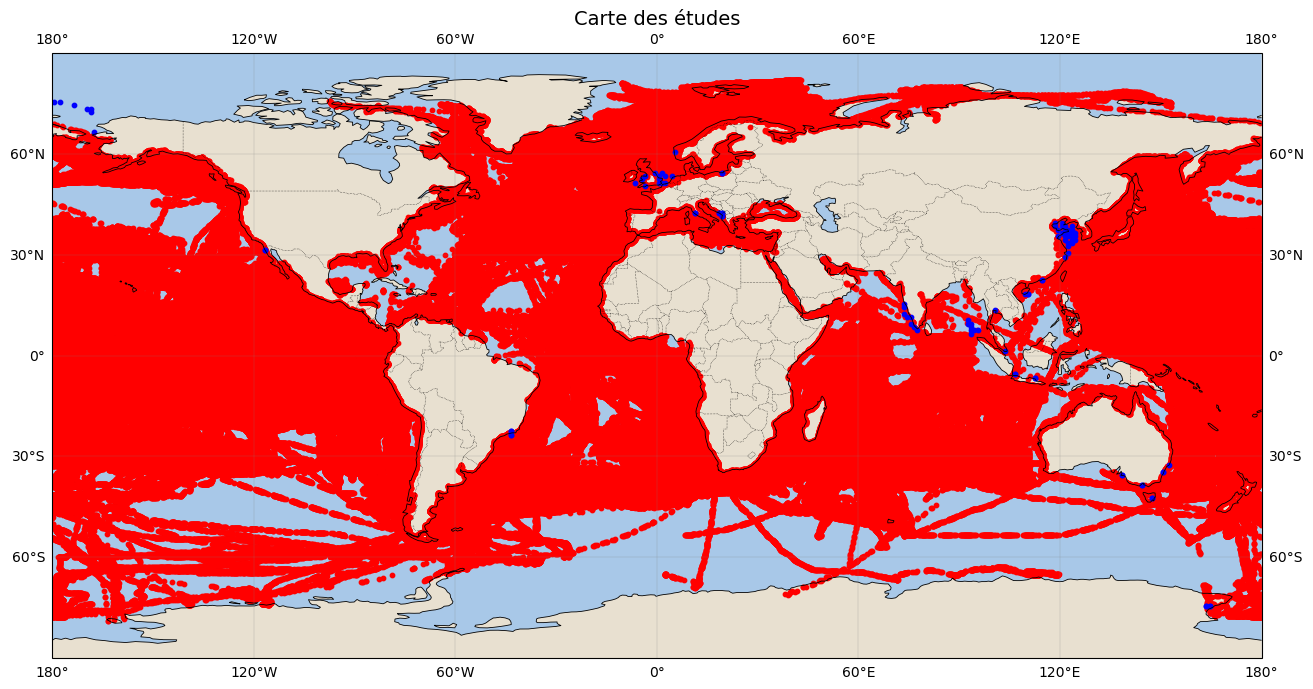

In [141]:
fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND,       facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN,      facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

ax.scatter(lons, lats, s=10, color="red", zorder=1, transform=ccrs.PlateCarree())
ax.scatter(lons_data, lats_data, s=10, color="blue", zorder=1, transform=ccrs.PlateCarree())

plt.title("Carte des études", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
def compute_distances(lat, lon, lats, lons):
    """Computes distances in km using the Haversine formula"""
    R = 6378
    lat1, lon1, lat2, lon2 = np.radians(lat), np.radians(lon), np.radians(lats), np.radians(lons)
    dLat = (lat2-lat1)
    dLon = (lon2-lon1)
    d = 2*R*np.arcsin(np.sqrt((np.sin(dLat/2))**2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dLon/2))**2))
    return d

points_arr = np.array(points_folder)
coords     = np.array([(p[0], p[1]) for p in points_folder], dtype=float)

In [8]:
def nearest_fishing_areas(method, lat, lon, coords, points_array):

    distances = compute_distances(lat, lon, coords[:, 0], coords[:, 1])
    
    # Find closest point
    if method == "nearest point":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        nearest = np.array(nearest, dtype=object)
        min_distance = distances[idx_nearest]
        return (min_distance, nearest[2])  # Return distance and parameters of nearest point
    
    if method == "sum of 5 nearests":
        idx_smallest_five = np.argpartition(distances, 5)[:5] # rearranges the indices so that the 5 smallest values are guaranteed to be in the first 5 positions of the result 
        nearby = points_array[idx_smallest_five]
        min_distances = distances[idx_smallest_five]
        nearby = np.nansum(nearby, axis=0)
        return (np.nansum(min_distances, axis=0), nearby[2])
    
    if method == "100 km radius":
        # All points within 100 km
        mask = distances <= 100
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0)
        min_distance = np.nanmean(distances[mask])
        return (min_distance, nearby[2])
    
    if method == "50 km radius":
        # All points within 50 km
        mask = distances <= 50
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0)
        min_distance = np.nanmean(distances[mask])
        return (min_distance, nearby[2])


In [9]:
result_np = []
result_sum5 = []
result_100km = []
result_50km = []

for lat, lon in zip(lats_data, lons_data):
    output = nearest_fishing_areas(method = "nearest point",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_np.append(output)
    
    output = nearest_fishing_areas(method = "sum of 5 nearests",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_sum5.append(output)

    output = nearest_fishing_areas(method = "100 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_100km.append(output)

    output = nearest_fishing_areas(method = "50 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_50km.append(output)

df_np = pd.DataFrame(result_np[i] for i in range(len(result_np)))
df_np = pd.concat([df_np.drop(1, axis=1),df_np[1].apply(pd.Series)], axis=1)
df_np.columns = ['Distance Fishing nearest_point', 'Fishing hours nearest_point']

df_sum5 = pd.DataFrame(result_sum5[i] for i in range(len(result_sum5)))
df_sum5 = pd.concat([df_sum5.drop(1, axis=1),df_sum5[1].apply(pd.Series)], axis=1)
df_sum5.columns = ['Distance Fishing sum5', 'Fishing hours sum5']

df_100km = pd.DataFrame(result_100km[i] for i in range(len(result_100km)))
df_100km = pd.concat([df_100km.drop(1, axis=1),df_100km[1].apply(pd.Series)], axis=1)
df_100km.columns = ['Distance Fishing 100km', 'Fishing hours 100km']

df_50km = pd.DataFrame(result_50km[i] for i in range(len(result_50km)))
df_50km = pd.concat([df_50km.drop(1, axis=1),df_50km[1].apply(pd.Series)], axis=1)
df_50km.columns = ['Distance Fishing 50km', 'Fishing hours 50km']

C:\Users\nelad\AppData\Local\Temp\ipykernel_22512\755978810.py:33: RuntimeWarning: Mean of empty slice
  min_distance = np.nanmean(distances[mask])
C:\Users\nelad\AppData\Local\Temp\ipykernel_22512\755978810.py:25: RuntimeWarning: Mean of empty slice
  min_distance = np.nanmean(distances[mask])


In [10]:
output = pd.concat([data, df_np,df_sum5, df_100km, df_50km], axis=1)
output

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance Fishing nearest_point,Fishing hours nearest_point,Distance Fishing sum5,Fishing hours sum5,Distance Fishing 100km,Fishing hours 100km,Distance Fishing 50km,Fishing hours 50km
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,42.960003,0.0,226.281575,0.202242,73.783234,23.902242,45.884545,0.328700
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,18.615710,0.0,112.654384,0.336333,64.394956,26.368575,34.087890,6.673325
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,34.639677,0.0,200.335166,3.919858,72.789767,6.648450,43.379742,3.919858
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,61.935745,0.0,326.949552,0.000000,83.335669,2.277617,NaN,0.000000
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,49.237943,0.0,285.879408,0.000000,76.047040,5.870692,49.237943,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,603.104773,0.0,3053.863357,0.000000,NaN,0.000000,NaN,0.000000
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,627.205322,0.0,3166.256406,0.000000,NaN,0.000000,NaN,0.000000
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,613.549220,0.0,3078.484941,0.000000,NaN,0.000000,NaN,0.000000
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,637.941396,0.0,3204.327162,0.000000,NaN,0.000000,NaN,0.000000


## Divide by distance

In [11]:
output_divided = output.copy()

# Remove infinities and zero values from distance denominators before normalization
keys = ['nearest_point', 'sum5', '100km', '50km']
for key in keys:
    dist = output_divided[f'Distance Fishing {key}'].replace({0: np.nan})
    output_divided[f'Fishing hours/Distance {key}'] = output_divided[f'Fishing hours {key}']/dist

In [12]:
output_divided

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance Fishing nearest_point,Fishing hours nearest_point,Distance Fishing sum5,Fishing hours sum5,Distance Fishing 100km,Fishing hours 100km,Distance Fishing 50km,Fishing hours 50km,Fishing hours/Distance nearest_point,Fishing hours/Distance sum5,Fishing hours/Distance 100km,Fishing hours/Distance 50km
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,42.960003,0.0,226.281575,0.202242,73.783234,23.902242,45.884545,0.328700,0.0,0.000894,0.323952,0.007164
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,18.615710,0.0,112.654384,0.336333,64.394956,26.368575,34.087890,6.673325,0.0,0.002986,0.409482,0.195768
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,34.639677,0.0,200.335166,3.919858,72.789767,6.648450,43.379742,3.919858,0.0,0.019567,0.091338,0.090361
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,61.935745,0.0,326.949552,0.000000,83.335669,2.277617,NaN,0.000000,0.0,0.000000,0.027331,NaN
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,49.237943,0.0,285.879408,0.000000,76.047040,5.870692,49.237943,0.000000,0.0,0.000000,0.077198,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,603.104773,0.0,3053.863357,0.000000,NaN,0.000000,NaN,0.000000,0.0,0.000000,NaN,NaN
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,627.205322,0.0,3166.256406,0.000000,NaN,0.000000,NaN,0.000000,0.0,0.000000,NaN,NaN
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,613.549220,0.0,3078.484941,0.000000,NaN,0.000000,NaN,0.000000,0.0,0.000000,NaN,NaN
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,637.941396,0.0,3204.327162,0.000000,NaN,0.000000,NaN,0.000000,0.0,0.000000,NaN,NaN


In [13]:
output_divided.to_csv('outputs\Fishing hours dataset.csv', index=False)

## Statistics

In [14]:
parameters = output_divided.columns[8:].tolist()
parameters

['Distance Fishing sum5',
 'Fishing hours sum5',
 'Distance Fishing 100km',
 'Fishing hours 100km',
 'Distance Fishing 50km',
 'Fishing hours 50km',
 'Fishing hours/Distance nearest_point',
 'Fishing hours/Distance sum5',
 'Fishing hours/Distance 100km',
 'Fishing hours/Distance 50km']

In [15]:
# Normalize data for statistics
output_divided_copy = output_divided.copy()
cols_to_normalize = ['MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
output_divided_copy[cols_to_normalize] = scaler.fit_transform(output_divided_copy[cols_to_normalize])

# Divide fibers from fragments
output_divided_fib = output_divided_copy[output_divided_copy["Shape"] == "Fibers"]
output_divided_frg = output_divided_copy[output_divided_copy["Shape"] == "Fragments"]

In [16]:
output_divided_fib

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance Fishing nearest_point,Fishing hours nearest_point,Distance Fishing sum5,Fishing hours sum5,Distance Fishing 100km,Fishing hours 100km,Distance Fishing 50km,Fishing hours 50km,Fishing hours/Distance nearest_point,Fishing hours/Distance sum5,Fishing hours/Distance 100km,Fishing hours/Distance 50km
0,Fibers,-74.5,163.5,0.000000e+00,NaN,1,42.960003,0.000000,0.058585,0.000084,0.739666,0.000163,0.862974,0.000010,0.000000,0.000015,0.000145,0.000008
1,Fibers,-74.5,164.5,5.077014e-09,1.732525e-07,10,18.615710,0.000000,0.023749,0.000139,0.598000,0.000179,0.380939,0.000213,0.000000,0.000050,0.000183,0.000210
2,Fibers,-42.5,147.5,1.317255e-04,NaN,1,34.639677,0.000000,0.050630,0.001620,0.724675,0.000045,0.760623,0.000125,0.000000,0.000325,0.000041,0.000097
3,Fibers,-38.5,144.5,1.763707e-04,NaN,1,61.935745,0.000000,0.089448,0.000000,0.883810,0.000015,NaN,0.000000,0.000000,0.000000,0.000012,NaN
4,Fibers,-35.5,138.5,1.224361e-04,NaN,1,49.237943,0.000000,0.076856,0.000000,0.773826,0.000040,1.000000,0.000000,0.000000,0.000000,0.000034,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Fibers,42.5,11.5,9.538178e-07,4.398004e-05,9,22.263420,0.022083,0.032048,0.090055,0.699713,0.072132,0.573603,0.077782,0.001373,0.025884,0.066631,0.067378
61,Fibers,42.5,18.5,1.171786e-06,3.968515e-05,8,13.834018,5.938233,0.018670,0.018820,0.629635,0.013532,0.424305,0.021702,0.594219,0.007866,0.013373,0.020754
62,Fibers,42.5,19.5,7.610573e-07,NaN,1,66.569780,0.000000,0.098628,0.000000,0.934850,0.000969,NaN,0.000000,0.000000,0.000000,0.000734,NaN
63,Fibers,54.5,19.5,4.259667e-07,2.108024e-05,7,0.000000,1.682475,0.001963,0.018176,0.528660,0.037421,0.255555,0.068553,NaN,0.017548,0.041119,0.074284


In [17]:
spearman_results = []

# Fibers

for key in parameters:
    x = output_divided_fib[key]
    y = output_divided_fib['MEAN MP stock (g/m2) in 2021']

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))
    

# Fragmanrts
for key in parameters:
    x = output_divided_frg[key]
    y = output_divided_frg['MEAN MP stock (g/m2) in 2021']

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))

# Both
for key in parameters:
    x = output_divided_copy[key]
    y = output_divided_copy['MEAN MP stock (g/m2) in 2021']

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)


    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))
    

In [18]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])

In [19]:
output_divided_fib

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance Fishing nearest_point,Fishing hours nearest_point,Distance Fishing sum5,Fishing hours sum5,Distance Fishing 100km,Fishing hours 100km,Distance Fishing 50km,Fishing hours 50km,Fishing hours/Distance nearest_point,Fishing hours/Distance sum5,Fishing hours/Distance 100km,Fishing hours/Distance 50km
0,Fibers,-74.5,163.5,0.000000e+00,NaN,1,42.960003,0.000000,0.058585,0.000084,0.739666,0.000163,0.862974,0.000010,0.000000,0.000015,0.000145,0.000008
1,Fibers,-74.5,164.5,5.077014e-09,1.732525e-07,10,18.615710,0.000000,0.023749,0.000139,0.598000,0.000179,0.380939,0.000213,0.000000,0.000050,0.000183,0.000210
2,Fibers,-42.5,147.5,1.317255e-04,NaN,1,34.639677,0.000000,0.050630,0.001620,0.724675,0.000045,0.760623,0.000125,0.000000,0.000325,0.000041,0.000097
3,Fibers,-38.5,144.5,1.763707e-04,NaN,1,61.935745,0.000000,0.089448,0.000000,0.883810,0.000015,NaN,0.000000,0.000000,0.000000,0.000012,NaN
4,Fibers,-35.5,138.5,1.224361e-04,NaN,1,49.237943,0.000000,0.076856,0.000000,0.773826,0.000040,1.000000,0.000000,0.000000,0.000000,0.000034,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Fibers,42.5,11.5,9.538178e-07,4.398004e-05,9,22.263420,0.022083,0.032048,0.090055,0.699713,0.072132,0.573603,0.077782,0.001373,0.025884,0.066631,0.067378
61,Fibers,42.5,18.5,1.171786e-06,3.968515e-05,8,13.834018,5.938233,0.018670,0.018820,0.629635,0.013532,0.424305,0.021702,0.594219,0.007866,0.013373,0.020754
62,Fibers,42.5,19.5,7.610573e-07,NaN,1,66.569780,0.000000,0.098628,0.000000,0.934850,0.000969,NaN,0.000000,0.000000,0.000000,0.000734,NaN
63,Fibers,54.5,19.5,4.259667e-07,2.108024e-05,7,0.000000,1.682475,0.001963,0.018176,0.528660,0.037421,0.255555,0.068553,NaN,0.017548,0.041119,0.074284


In [20]:
strong_parameters =  []
for row in range(len(results_stats)):
    if np.abs(results_stats['Spearman Correlation'].iloc[row]) > 0.3:

        strong_parameters.append(results_stats.iloc[row])
strong_parameters


[Parameter               Distance Fishing sum5 fibers stock
 Spearman Correlation                             -0.494218
 Spearman p-value                                  0.000029
 Name: 0, dtype: object,
 Parameter               Fishing hours sum5 fibers stock
 Spearman Correlation                           0.440715
 Spearman p-value                               0.000239
 Name: 1, dtype: object,
 Parameter               Fishing hours 100km fibers stock
 Spearman Correlation                            0.454864
 Spearman p-value                                0.000141
 Name: 3, dtype: object,
 Parameter               Fishing hours 50km fibers stock
 Spearman Correlation                           0.403452
 Spearman p-value                               0.000861
 Name: 5, dtype: object,
 Parameter               Fishing hours/Distance nearest_point fibers stock
 Spearman Correlation                                             0.364121
 Spearman p-value                                     

In [21]:
strong_parameters

[Parameter               Distance Fishing sum5 fibers stock
 Spearman Correlation                             -0.494218
 Spearman p-value                                  0.000029
 Name: 0, dtype: object,
 Parameter               Fishing hours sum5 fibers stock
 Spearman Correlation                           0.440715
 Spearman p-value                               0.000239
 Name: 1, dtype: object,
 Parameter               Fishing hours 100km fibers stock
 Spearman Correlation                            0.454864
 Spearman p-value                                0.000141
 Name: 3, dtype: object,
 Parameter               Fishing hours 50km fibers stock
 Spearman Correlation                           0.403452
 Spearman p-value                               0.000861
 Name: 5, dtype: object,
 Parameter               Fishing hours/Distance nearest_point fibers stock
 Spearman Correlation                                             0.364121
 Spearman p-value                                     